# Model Evaluation: Perplexity and Loss
This notebook runs the post-training evaluation across the separate datasets (`bng`, `eng`, `translation`) and visualizes the results.

In [1]:
# 1. Run the Evaluation Script
# !python ../src/eval/perplexity_loss_eval.py --model_dir ../saved/model/default --data_dir ../saved/data/eval --report_dir ../saved/reports

In [2]:
# 2. Load the YAML Report
import yaml
import pandas as pd

report_path = "../saved/reports/eval_results.yaml"
with open(report_path, "r") as f:
    results = yaml.safe_load(f)["evaluations"]

df = pd.DataFrame.from_dict(results, orient="index")
display(df)

,total_loss,ce_loss,z_loss,perplexity,batches
translation,1.5140,1.5102,0.0038,4.5276,1809
eng,2.9581,2.9496,0.0085,19.0982,12500
bng,3.3583,3.3505,0.0078,28.5176,25000
overall,2.6101,2.6034,0.0067,17.3811,39309


/tmp/ipykernel_110834/4203281253.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y="perplexity", data=df, palette="viridis")


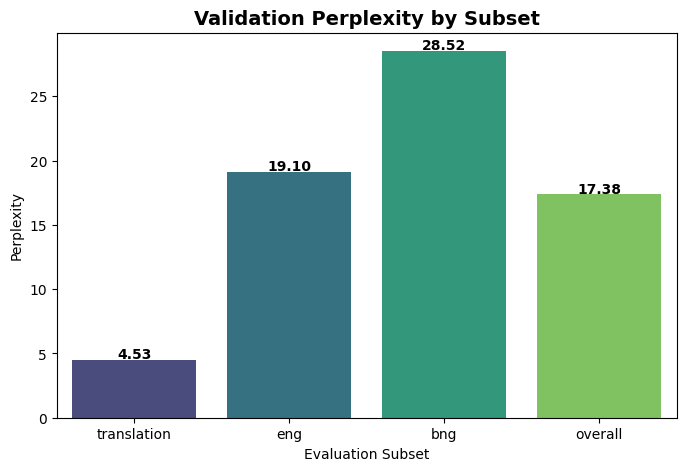

In [3]:
# 3. Visualize Perplexity
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=df.index, y="perplexity", data=df, palette="viridis")
plt.title("Validation Perplexity by Subset", fontsize=14, fontweight="bold")
plt.ylabel("Perplexity")
plt.xlabel("Evaluation Subset")
for i, v in enumerate(df["perplexity"]):
    plt.text(i, v + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()